# 01 · Claude Agent SDK 入門（零基礎到動手做）

> **教學目標**：40～50 分鐘內，從「零」到「寫出一個擁有自訂工具、具備安全邊界、且完全看得見內部思考與調用軌跡的 AI Agent」。  
> **先備知識**：基本的 Python 語法（函式、字典、async/await 基本概念）。不需要先懂複雜的 Agent 框架！  
> **系列定位**：本篇是整個 Agentic RAG 工作坊的**地基篇**。下一本 `02_compose_architectures.ipynb` 會直接用這裡學到的四大核心技術，組裝出業界知名的 CRAG、Self-RAG、Adaptive-RAG 等進階架構。

---

### 🧠 核心心智模型（Mental Model）：一般 LLM vs AI Agent

在開始寫程式之前，請先建立這張清晰的心智模型。教學時用這個比喻，初學者最容易秒懂：

```
傳統 LLM 對話（單純語言模型）
┌────────────────────────────────────────┐
│  使用者提問 ──▶ [ LLM 大腦 (純文字計算) ] ──▶ 產生回覆  │
│  (局限：無法連網、無法查私有資料庫、無法計算、容易一本正經胡說八道) │
└────────────────────────────────────────┘

AI Agent（智慧代理架構）
┌─────────────────────────────────────────────────────────────────┐
│                     [ LLM 大腦：決策與推理中樞 ]                      │
│                           ▲              │                      │
│            觀察回傳 (Observation)     決定行動 (Action)          │
│                           │              ▼                      │
│  ┌────────────────────────┴──────────────┴────────────────────┐ │
│  │                     [ 手與腳：Tools / MCP ]                 │ │
│  │  - 搜尋知識庫 (RAG)                                         │ │
│  │  - 呼叫自訂 Python 函式 (計算、查天氣、擲骰子、跑模型)         │ │
│  │  - 存取外部 API / 終端環境                                   │ │
│  └────────────────────────────────────────────────────────────┘ │
│                                                                 │
│  🔍 [ 監視器：Hooks (PreToolUse / PostToolUse) ] 記錄每一步軌跡   │
└─────────────────────────────────────────────────────────────────┘
```

- **單純 LLM**：就像一個「只有大腦、被關在沒有窗戶房間裡的學者」。你問他什麼，他只能憑記憶回答，沒看過的就只能瞎猜。
- **AI Agent**：幫這個學者裝上**手和腳（工具/MCP）**與**眼睛（觀察回饋）**。當他遇到不懂或需要精確計算的事，他會主動拿起計算機或走進資料庫查詢，確認結果後再向你回報。

---

### 🗺️ 本單元的「四大基石」學習路徑

1. **Step 0 & 1 · 跑起來 (Run)**：掌握認證方式，用 `query()` 跑通最簡的一問一答。
2. **Step 2 · 給工具 (Equip)**：用 `@tool` 與 in-process MCP 把 Python 函式打包成 Agent 的手腳。
3. **Step 2.5 · 設邊界 (Constrain)**：用 `tools=[]` 與 `setting_sources=[]` 建立嚴格安全沙盒，避免 Agent 失控。
4. **Step 3 · 裝監視器 (Observe)**：用 `Hook` 打開黑盒子，印出完整調用軌跡（Trace），讓 Agent 的每一步思考與動作完全透明可查。


## Step 0 · 認證設定：四種接法完全拆解

Claude Agent SDK 提供了高度彈性的後端連接方式。根據你的使用情境（課堂教學、公司專案、個人實驗），選擇以下其中一種即可：

| 接法 | 適用情境 | 怎麼設定（在 `.env` 或終端機） | 費用與額度來源 |
|---|---|---|---|
| **1. 本機已登入 Claude Code** | 最推薦！日常開發者、最無腦 | 本機終端機跑過 `claude login` 即可，**什麼都不用設** | 扣 Claude 訂閱帳號額度（Pro / Max / Team） |
| **2. OAuth Token** | CI/CD 環境、共用伺服器 | 終端機跑 `claude setup-token`，產生的字串填入 `.env` 的 `CLAUDE_CODE_OAUTH_TOKEN="..."` | 扣產生 Token 的 Claude 帳號額度 |
| **3. 第三方相容 API / Proxy** | 企業內網、想換 DeepSeek / Kimi / 自架 LiteLLM | 在 `.env` 設定：<br>`ANTHROPIC_BASE_URL="http://..."`<br>`ANTHROPIC_AUTH_TOKEN="sk-..."` | 依所接的供應商或 Proxy 計費 |
| **4. Anthropic 官方 API Key** | 標準雲端部署、官方 API 開發者 | 在 `.env` 設定：<br>`ANTHROPIC_API_KEY="sk-ant-..."` | 依 Anthropic 官方 Token 費率計費 |

> 💡 **教學重點**：  
> 第三種接法非常強大！如果你想用開源模型（如 Ollama / vLLM）或國產大模型（DeepSeek、GLM），只要透過 LiteLLM 轉成 Anthropic 相容規格，**下面的所有程式碼完全不需要改動任何一行**，真正達成跨模型零痛點切換。


In [2]:
# ── 這格在做什麼：初始化環境、路徑定位、載入認證、確認套件與 Kernel ──
import os, sys, json
from pathlib import Path

# 【觀念 1：為什麼要切換工作目錄？】
# 當你在 VS Code 或 JupyterLab 打開這個檔案時，Python 預設的「工作目錄 (CWD)」是在 notebooks/ 資料夾下。
# 但本專案的核心模組（如 modules.py、retrieval.py）都存放在專案根目錄（上一層 ..）。
# 如果不切換，後面寫 `import retrieval` 就會跳出 `ModuleNotFoundError`。
# 這裡先檢查當前目錄名稱是不是 "notebooks"，是才往上一層退；避免重複執行這格時一路退到根目錄外。
if Path.cwd().name == "notebooks":
    os.chdir("..")                       # 將當前工作目錄切換到專案根目錄
sys.path.insert(0, str(Path.cwd()))      # 將專案根目錄插到 sys.path 的最前端（優先搜尋）

# 【觀念 2：載入環境變數】
# .env 是存放敏感金鑰的檔案（例如 API 金鑰、Token）。
# load_dotenv() 會自動讀取專案根目錄下的 .env 檔案，並注入系統環境變數中，
# 這樣後續程式碼就能用 os.getenv("變數名") 安全取得，不必將金鑰寫死在程式碼中。
from dotenv import load_dotenv
load_dotenv()

# 【觀念 3：防呆機制 —— 確保 Kernel 選對 Python 環境】
# 初學者最常踩的坑：VS Code 打開 .ipynb 時常自作聰明建立一個乾淨卻沒有套件的 notebooks/.venv。
# 這裡主動做 import 測試，若找不到套件就印出白話指引，不用讓學生看著報錯發呆猜測。
try:
    import claude_agent_sdk
except ModuleNotFoundError:
    print("❌ 錯誤：目前的 Python Kernel 找不到 claude_agent_sdk！")
    print(f"👉 目前 Kernel 使用的路徑是：{sys.executable}")
    print("💡 解決方法：")
    print("   1. 請點選 VS Code 右上角的「Select Kernel」")
    print("   2. 選擇「Python Environments」")
    print("   3. 指向專案根目錄的 .venv（即使用 `uv sync` 建立的環境，Python 3.13）")
    raise

print("✅ SDK 載入成功！版本：", claude_agent_sdk.__version__)

# 【觀念 4：檢查當前生效的認證方式】
# 這裡示範 Python 少見但實用的 for...else 語法：
# 只有當迴圈「完整跑完且沒有觸發 break」時，才會執行 else 區塊。
# 意思是：如果四個環境變數都沒找到，就執行 else 中的提示。
auth_keys = ["CLAUDE_CODE_OAUTH_TOKEN", "ANTHROPIC_BASE_URL", "ANTHROPIC_AUTH_TOKEN", "ANTHROPIC_API_KEY"]
for key in auth_keys:
    if os.getenv(key):
        print(f"🔑 偵測到認證設定：{key}")
        break
else:
    print("ℹ️ 未偵測到任何顯式認證環境變數。如果本機已執行過 `claude login`，SDK 將自動沿用本機登入憑證。")

# ── kernel 對不對，看這一行就夠 ──
# 選單上叫什麼名字不重要（VS Code 顯示路徑、Jupyter Lab 顯示名字），
# 重要的是這支 python 是不是專案的 .venv。是的話下面每一格都 import 得到。
print('kernel 用的 python：', sys.executable)
print('工作目錄　　　　　：', Path.cwd())


✅ SDK 載入成功！版本： 0.2.152
ℹ️ 未偵測到任何顯式認證環境變數。如果本機已執行過 `claude login`，SDK 將自動沿用本機登入憑證。
kernel 用的 python： /Users/awesomeartengineer01/agentic-rag-workshop/.venv/bin/python3
工作目錄　　　　　： /Users/awesomeartengineer01/agentic-rag-workshop


## Step 1 · 最小可跑：一問一答（Hello World）

在把問題複雜化（加工具、加檢索）之前，第一步永遠是**先跑通最小可運作管線（Pipeline）**。

### `query()` 是什麼？
`query()` 是 Claude Agent SDK 中最輕量、最直接的高階入口函式。
- **輸入**：你的問題提示詞（`prompt`）與執行設定選項（`options`）。
- **底層運作**：SDK 會在背後喚起 Claude CLI 子程序，透過標準輸入輸出（stdio）建立雙向溝通，並將模型的回應轉換為結構化的訊息串流（Message Stream）。
- **輸出**：一個非同步產生器（Async Generator），隨著模型生成內容，逐筆回傳 `message` 物件。

> 💡 **為什麼使用 `async for` 接收回應？**  
> 大型語言模型的回應是一段一段產生的（串流 Streaming）。使用 `async for` 可以讓你在模型輸出的瞬間就接收到封包，不必乾等 10 秒拿完整段文字，使用者體驗極佳。


In [3]:
from claude_agent_sdk import query, ClaudeAgentOptions, AssistantMessage, TextBlock

# ── 【解說：如何呼叫 query() 並解析串流訊息】 ──
# 
# 1. 為什麼這裡可以直接寫 async for 而不用定義 async def main()？
#    因為 Jupyter Notebook 的每個 cell 底層本來就跑在 asyncio 事件迴圈（Event Loop）中。
#    如果在一般純 Python 腳本（.py）執行，必須將其包在 async def main() 內，並呼叫 asyncio.run(main())。
#
# 2. ClaudeAgentOptions 的防禦性參數：
#    - tools=[]: 關閉所有內建工具。初次測試我們只想確認模型純文字對話正常，不給工具。
#    - setting_sources=[]: 乾淨沙盒模式，不載入本地的 CLAUDE.md 或專案 hooks。
#    - max_turns=1: 限制只來回對話 1 次就結束，避免迴圈失控。

print("正在發送請求給 Claude...")

async for message in query(
    prompt="用一句話說明 RAG 是什麼，不要超過 30 個字。",
    options=ClaudeAgentOptions(
        tools=[],            # 嚴格關閉內建工具（如 Read/Write/Bash）
        setting_sources=[],  # 隔離專案外部設定檔
        max_turns=1,         # 單輪問答
    ),
):
    # 【觀念：Message 的型別分類】
    # SDK 串流回來的 message 包含多種類型：
    # - AssistantMessage: 助手（模型）輸出的訊息（包含思考、文字或工具呼叫請求）
    # - UserMessage: 使用者的輸入
    # - SystemMessage: 系統層級的通知
    # - ResultMessage: 執行結束後的統計摘要（例如 token 用量、花費時間）
    # 我們目前只關心「模型回了什麼」，所以用 isinstance 篩選出 AssistantMessage。
    if isinstance(message, AssistantMessage):
        # 【觀念：Content Blocks 結構】
        # AssistantMessage.content 是一個清單，裡面包含多個內容區塊（Blocks）：
        # - TextBlock: 純文字回覆內容（block.text）
        # - ToolUseBlock: 模型決定呼叫工具的請求（包含工具名與傳入參數）
        # - ThinkingBlock: 模型內部的延伸思考過程（Extended Thinking）
        for block in message.content:
            if isinstance(block, TextBlock):
                print("模型回覆：", block.text)


正在發送請求給 Claude...
模型回覆： RAG 是讓模型先檢索外部資料，再依據檢索結果生成回答的技術。


### ⚠️ 兩個選項現在就要養成習慣寫：Agent 安全沙盒法則

在開發任何 AI Agent 專案時，**安全性（Security Sandbox）與確定性（Determinism）永遠是第一考量**：

| 選項 | 設定值 | 為什麼一定要寫？（原理深究） |
|---|---|---|
| `tools` | `[]` | **關閉所有預設工具**。<br>Claude Code SDK 預設帶有強大的系統級工具（如 `Bash` 執行終端指令、`Write` 寫入檔案、`Read` 讀取硬碟）。如果你做的是一個專案檢索 RAG Agent，你絕對不希望 Agent 在你不知情的情況下執行終端機命令或修改本機檔案！設為 `[]` 才能確保「只開放我們明文允許的工具」。 |
| `setting_sources` | `[]` | **隔離專案設定**。<br>預設情況下，SDK 會去掃描工作目錄下的 `CLAUDE.md`、專案設定檔或全域 hooks。這可能導致你在不同電腦或不同目錄下執行時，Agent 的行為受到隱藏設定影響。設為 `[]` 能保證你的 Agent 是「一張白紙」，行為完全可重現（Reproducible）。 |

---

> 🚨 **初學者與工程師極常踩的大坑：`tools` vs `allowed_tools` 的差別！**
> 
> - **`tools`（能力清單）**：控制 Agent「能不能看到並使用」這項能力。設為 `[]` 代表 Agent 根本沒有這些手腳。
> - **`allowed_tools`（免問放行名單）**：控制 Agent 呼叫該工具時「要不要停下來等人類在終端機按 Enter 確認（Y/N）」。
> 
> 很多新手誤以為「我只要在 `allowed_tools` 裡面只寫 my_tool，Agent 就不會用 Bash 了」，**這是完全錯誤的**！如果 `tools` 沒關閉，Agent 依然能看見 Bash 工具，當它想用時只是會卡住等待終端機授權。要真正禁用，**必須顯式設定 `tools=[]`**！


## Step 2 · 第一個自訂工具：把 Python 函式變成 Agent 的「手」

現在模型已經會講話了，但它還沒有「手和腳」。這一步我們要賦予它呼叫 Python 程式的能力。

### 什麼是 MCP（Model Context Protocol）？
過去每個大模型框架（LangChain, AutoGen, CrewAI）都有自己定義工具的一套寫法，互不相容。  
**MCP 是 Anthropic 發起的開放協定標準**，就像電子裝置的 **USB-C** 規範一樣：
只要把你的工具做成 MCP 標準，任何支援 MCP 的 Agent（不管是 Claude、未來其他 LLM、還是 IDE）都能直接插上使用。

### 什麼是「In-process MCP Server」？
聽起來像要在背景啟動 HTTP 或 WebSocket 伺服器？**完全不用！**  
SDK 提供的 `create_sdk_mcp_server` 是 **In-process（同程序內）** 執行的：
它直接運行在當前 Notebook 的 Python 記憶體空間中，沒有網路開銷、沒有連線延遲、不佔用額外連接埠，是教學與快速實驗的最佳利器。

---

### 🎲 為什麼教學第一課一定要拿「擲骰子」當例子？

很多教學一開始就串聯複雜的資料庫或搜尋引擎，結果學生卡在網路逾時或 API 金鑰，根本不知道是 Agent 的問題還是網路的問題。  
**「擲骰子」是驗證 Agent 能力最完美的最小範例（Minimal Reproducible Example）**：

1. **LLM 天生無法產生真正的隨機數**：語言模型本質上是文字機率預測器，它沒有內建硬體亂數產生器。面對「擲一顆 20 面骰」，它要嘛呼叫亂數工具，要嘛就是自己編一個假數字（幻覺）。
2. **測試意圖理解與參數萃取（Parameter Extraction）**：
   - 使用者說：「幫我擲三顆 **20 面** 骰子」。
   - 模型必須從人類口語中理解「20 面」代表工具參數 `sides=20`。
3. **測試推理與連續行動（Sequential Actions）**：
   - 使用者說：「擲**三顆**」。
   - 模型是偷懶只擲一次然後乘以 3？還是乖乖**連續呼叫三次**工具？（這個真相在 Step 3 的 Hook 追蹤器下一覽無遺！）
   - 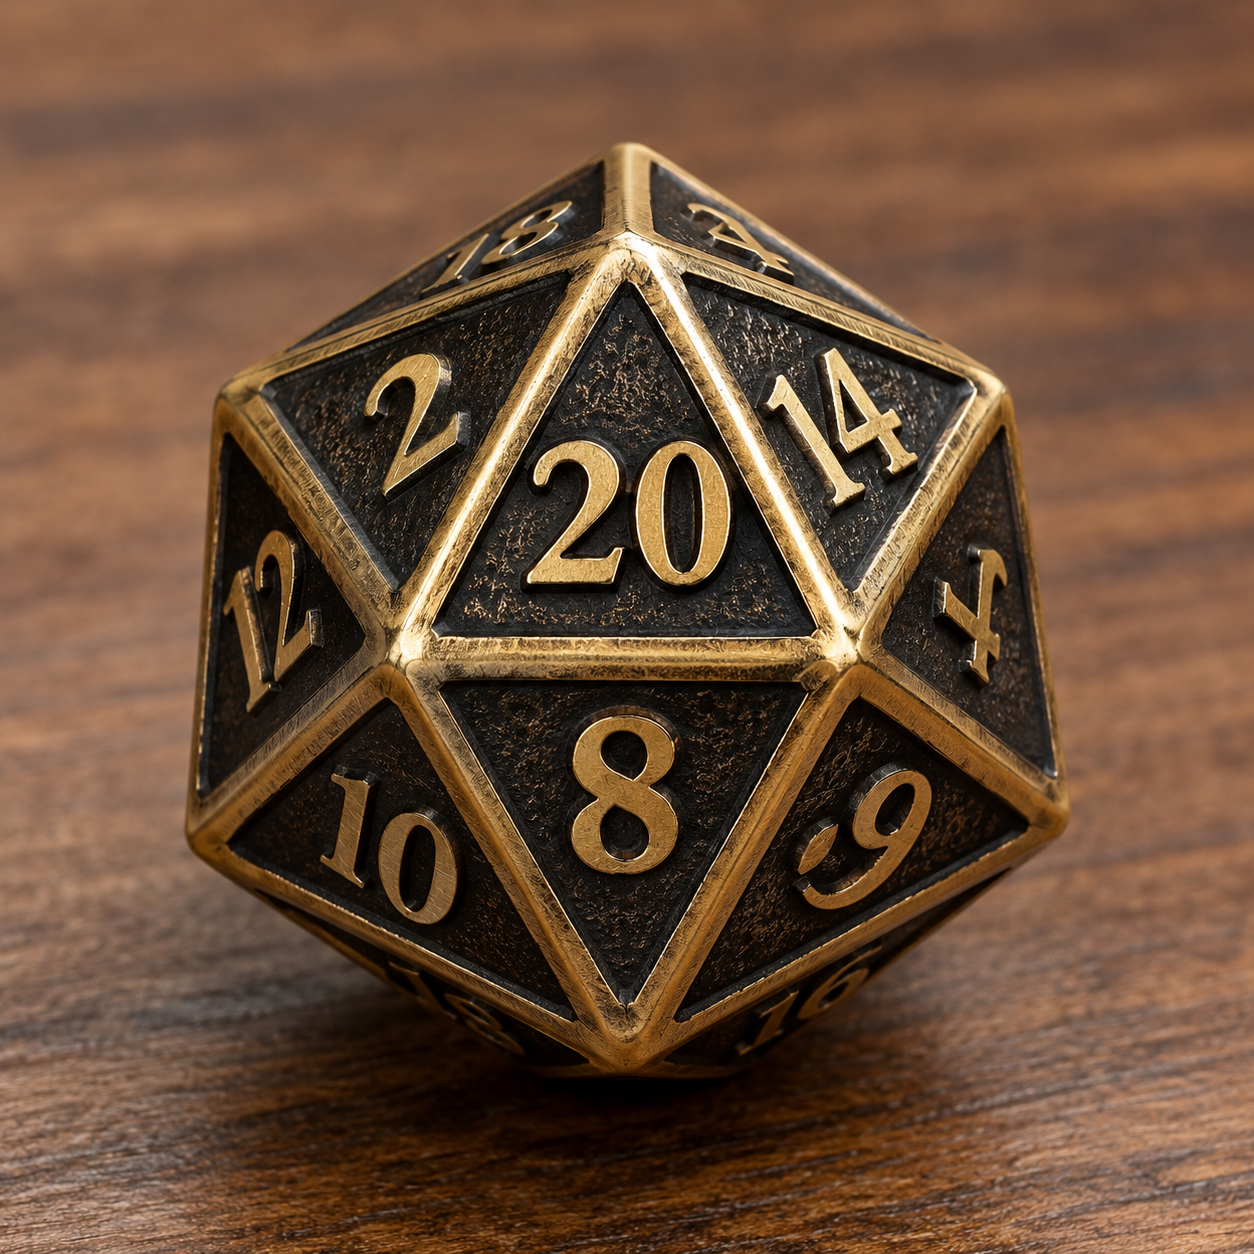


In [3]:
from claude_agent_sdk import tool, create_sdk_mcp_server
import random

# ── 【核心：使用 @tool 裝飾器定義工具】 ──
#
# @tool 裝飾器的功能：將一般的 Python 函式轉換為大語言模型看得懂的「工具描述規格」。
# 它接收三個關鍵參數：
# 1. name (字串): 工具名稱。模型在做出決策時，就是指定這個名稱來呼叫。
# 2. description (字串): 工具說明。極端重要！大語言模型「完全是靠這段文字」來判斷什麼時候該呼叫這個工具、它有什麼用。寫得模糊模型就會用錯。
# 3. input_schema (字典 - JSON Schema 規格): 定義傳入參數的型別與規則。
@tool(
    name="roll_dice",
    description="擲一顆骰子並取得隨機點數。當使用者需要隨機數字或擲骰時使用。sides 代表骰子的面數（例如 6 代表六面骰，20 代表二十面骰），預設值為 6。",
    input_schema={
        "type": "object",
        "properties": {
            "sides": {
                "type": "integer",
                "description": "骰子的面數（必須是正整數，例如 4, 6, 8, 12, 20, 100）"
            }
        },
        "required": []  # 空清單表示 sides 參數為選填（Optional），使用者不指定時使用預設值
    }
)
async def roll_dice(args: dict) -> dict:
    """
    工具的實際 Python 實作邏輯。
    
    【參數規格】
    - args: 模型解析使用者語意後，填入的參數字典。例如 {"sides": 20}。
            如果模型沒給 sides，args 就會是 {}。
            
    【回傳規格（MCP 標準）】
    - 必須回傳一個符合 MCP 協定的字典：
      {"content": [{"type": "text", "text": "你的回傳內容字串"}]}
    """
    # 安全取值：若 args 內沒有 sides，預設擲六面骰 (6)
    sides = args.get("sides", 6)
    
    # 真實隨機性：透過 Python random 模組在 1 到 sides 之間產生均勻隨機整數
    point = random.randint(1, sides)
    
    # 為什麼要把結果包成 JSON 字串？
    # 因為對 LLM 而言，結構化的 JSON 字串（如 {"sides": 20, "result": 17}）
    # 比純文字 "你擲出了 17" 更不易產生理解歧義，方便模型精確提取數值並進行後續計算。
    payload = json.dumps({"sides": sides, "result": point})
    
    return {
        "content": [
            {
                "type": "text",
                "text": payload
            }
        ]
    }

# ── 【核心：打包為 In-process MCP Server】 ──
# 參數依序為：
# 1. server_name: "demo"（這個名字會成為後續工具前綴的一部分）
# 2. version: "1.0.0"（伺服器版本號）
# 3. tools: [roll_dice]（掛載在這個伺服器下的工具函式清單）
dice_server = create_sdk_mcp_server("demo", "1.0.0", [roll_dice])

print("✅ 自訂 MCP 工具 [roll_dice] 註冊成功，已掛載至 'demo' 伺服器！")


✅ 自訂 MCP 工具 [roll_dice] 註冊成功，已掛載至 'demo' 伺服器！


### 命名空間（Namespacing）：工具全名的結構解析

當你透過 `create_sdk_mcp_server("demo", ...)` 將工具註冊後，SDK 為了避免不同 MCP Server 之間的工具名稱撞名（例如另一個 server 也有 `search`），會自動加上統一的前綴命名空間：

$$\text{完整工具名稱} = \texttt{mcp\_\_}\langle\text{server\_name}\rangle\texttt{\_\_}\langle\text{tool\_name}\rangle$$

例如：
- Server 名稱：`demo`
- 工具函式名稱：`roll_dice`
- **模型在背後看到的完整全名**：`mcp__demo__roll_dice`

> ⚠️ **新手設定常犯錯誤**：  
> 後續在設定 `allowed_tools` 免問放行名單時，**必須填寫完整名稱 `mcp__demo__roll_dice`**，如果只寫 `roll_dice`，SDK 會認不得它，導致工具被權限系統擋下來！


In [4]:
# ── 這格在做什麼：把做好的 MCP 工具掛載給 Agent，並請他擲三顆 20 面骰 ──

# 詳細剖析 ClaudeAgentOptions 的每一個參數細節：
options = ClaudeAgentOptions(
    tools=[],                                      # 1. 內建工具（Bash/Write等）全關，打造安全純淨環境
    mcp_servers={"demo": dice_server},             # 2. 掛載剛建立的 in-process MCP server，key 必須對應 server 名稱
    allowed_tools=["mcp__demo__roll_dice"],        # 3. 白名單自動放行：遇到此工具直接執行，不中斷等待人工審核
    strict_mcp_config=True,                        # 4. 嚴格模式：僅讀取本程式宣告的 MCP server，忽略本機其他全域設定
    setting_sources=[],                            # 5. 忽略外部設定檔干擾
    system_prompt=(                                # 6. 系統提示詞（System Prompt / Policy）：規範行為準則
        "你是一個專業的擲骰助手。"
        "當使用者要求擲骰時，你必須嚴格呼叫提供的工具獲取隨機數，絕對不能自行腦補或編造數字。"
        "取得所有點數後，計算加總，以繁體中文簡明回覆結果，不要冗長開場白。"
    ),
    max_turns=5,                                   # 7. 最大輪次（Turn）：
                                                   #    什麼是一輪？【模型發起呼叫 -> 工具執行 -> 回傳結果】算一輪。
                                                   #    擲 3 顆骰子代表至少需要 3 輪工具呼叫 + 1 輪最終回答文字 = 4 輪。
                                                   #    設定為 5 給予足夠寬限空間，同時防止無窮無盡的死循環。
)

print("🎲 向 Agent 下達任務：『幫我擲三顆 20 面骰，然後告訴我總和。』\n")

async for message in query(
    prompt="幫我擲三顆 20 面骰，然後告訴我總和。",
    options=options
):
    if isinstance(message, AssistantMessage):
        for block in message.content:
            if isinstance(block, TextBlock):
                print(block.text)

# ── 思考時間（給學生的提問） ──
# 看到上面輸出的總和了嗎？看似非常順利，但身為嚴謹的工程師，請思考：
# 「你怎麼知道模型真的有擲三次 20 面骰？他會不會只擲了一次然後自己心算乘三？或者根本連工具都沒呼叫，直接隨便說了個數字？」
# 目前這格完全看不出來！這就是為什麼我們需要 Step 3 的 Hook 機制。


🎲 向 Agent 下達任務：『幫我擲三顆 20 面骰，然後告訴我總和。』



三顆 20 面骰結果：13、2、17

總和：**32**


## Step 3 · 用 Hook 看見 Agent 在做什麼：可觀測性（Observability）

在上一步，我們只能在終端機看到最後的那段文字結論。**中間 Agent 到底想了什麼、呼叫了幾次工具、傳入什麼參數、工具回傳什麼原始數據，完全是個黑盒子！**

### 什麼是 Hook？
在軟體架構中，Hook（掛鉤 / 攔截器）就像是在工廠傳送帶旁安插的「檢驗員」或「行車記錄器」。  
在 Claude Agent SDK 中，你可以設定兩種最重要的生命週期掛鉤：

1. **`PreToolUse`**：在 Agent **即將**執行某個工具的那一瞬間觸發。
   - 你能看到：模型填寫的工具名稱、傳入的參數字典。
   - 應用：記錄稽核日誌（Audit Log）、檢查參數合法性（安全防護）、甚至可以回傳拒絕指令攔截危險操作。
2. **`PostToolUse`**：在工具執行完畢、準備把資料餵回給模型的那一瞬間觸發。
   - 你能看到：工具輸出的真實結果資料。
   - 應用：記錄工具回傳耗時、快取結果、或進行輸出格式遮罩（Masking 去除敏感個資）。

---

### 🔄 完整生命週期與 Hook 攔截流程圖

```
使用者 Prompt:「擲三顆 20 面骰」
       │
       ▼
   [ LLM 大腦 ] 思考：「我需要一顆 20 面骰，準備呼叫 roll_dice」
       │
       ├──────────────────────────────────────────────────┐
       ▼                                                  │
 🚨 【PreToolUse Hook 觸發】                               │
    - 攔截到參數: {"sides": 20}                            │
    - 動作: 記錄進 trace 清單，回傳 {} 放行                   │
       │                                                  │
       ▼                                                  │ 重複 3 次
   [ Python 工具實作: roll_dice ] 隨機產生 14              │ (每次一輪)
       │                                                  │
       ▼                                                  │
 📋 【PostToolUse Hook 觸發】                              │
    - 攔截到回傳: {"sides": 20, "result": 14}             │
    - 動作: 記錄進 trace 清單，回傳 {} 放行                   │
       │                                                  │
       ▼                                                  │
   [ LLM 大腦 ] 收到結果 14，評估還需要再擲兩次 ───────────────┘
       │
       ▼ (擲完 3 次後)
   [ LLM 大腦 ] 總結點數並計算總和
       │
       ▼
 終端輸出最終文字回覆
```

> 🎯 **教學關鍵概念**：  
> 沒有 Hook 的 Agent，你只能「盲目相信」它；有 Hook 的 Agent，它才是一個「具備可解釋性（Explainability）與可驗證性（Verifiability）的工程系統」。  
> 在下一本 Notebook 的 RAG 評測中，我們就是**完全依靠 Hook** 來抓出模型有沒有作弊、檢索有沒有命中的關鍵鐵證！


In [5]:
from claude_agent_sdk import HookMatcher

# ── 【第一步：準備一個記錄軌跡（Trace）的清單容器】 ──
# 每次 Hook 被觸發時，我們就把動作細節 append 進這個 trace 清單，跑完後印出來展示。
trace = []

# ── 【第二步：定義 PreToolUse Hook 回呼函式（Callback）】 ──
# SDK 嚴格規定 Hook 函式的簽名格式必須是：async def fn(data, tool_use_id, context) -> dict
# - data: 字典，包含本次調用的工具全名 `data["tool_name"]` 與參數 `data["tool_input"]`
# - tool_use_id: 每次呼叫的唯一 ID 字串（可用來跟 PostToolUse 配對）
# - context: 上下文環境物件
async def on_pre_tool(data, tool_use_id, context):
    # 工具全名格式例如 "mcp__demo__roll_dice"
    # rsplit("__", 1)[-1] 是常見小技巧：從右邊切開，只保留最後的函式名 "roll_dice"，讓日誌更乾淨
    tool_short_name = data["tool_name"].rsplit("__", 1)[-1]
    tool_args = data.get("tool_input", {})
    
    # 紀錄軌跡：(類型, 工具簡名, 傳入參數)
    trace.append(("CALL (呼叫)", tool_short_name, tool_args))
    
    # 關鍵回傳值：
    # 回傳空字典 {} 代表「驗證通過，放行執行」。
    # 如果想拒絕執行（例如參數違規），可回傳帶有拒絕原因的結構（詳見官方 SDK 文件）。
    return {}

# ── 【第三步：定義 PostToolUse Hook 回呼函式】 ──
async def on_post_tool(data, tool_use_id, context):
    tool_short_name = data["tool_name"].rsplit("__", 1)[-1]
    
    # data["tool_response"] 是工具回傳的 content 區塊清單
    blocks = data.get("tool_response")
    
    # 防禦性解析：標準格式下 blocks 是 [{"type": "text", "text": "..."}]
    if isinstance(blocks, list) and len(blocks) > 0 and "text" in blocks[0]:
        response_text = blocks[0]["text"]
    else:
        response_text = str(blocks)
        
    # 紀錄軌跡：(類型, 工具簡名, 工具回傳結果 - 截取前 80 字元防止長文本刷屏)
    trace.append(("RET  (回傳)", tool_short_name, response_text[:80]))
    return {}

# ── 【第四步：把 Hook 註冊進 ClaudeAgentOptions】 ──
options_with_hooks = ClaudeAgentOptions(
    tools=[],
    mcp_servers={"demo": dice_server},
    allowed_tools=["mcp__demo__roll_dice"],
    strict_mcp_config=True,
    setting_sources=[],
    system_prompt="你是一個嚴謹的擲骰助手。請依指示呼叫工具擲骰，最後以繁體中文回報各次點數與加總，不要客套贅字。",
    max_turns=8,  # 調高輪次上限，確保 3 次擲骰與總結能順利走完
    
    # 核心新設定：hooks 字典
    # 結構：{"事件名稱": [HookMatcher(...)]}
    # HookMatcher 如果不給 matcher 參數，代表「匹配攔截所有工具」；
    # 也可以透過 matcher="mcp__demo__.*" 等正規表示式只精確監控特定工具。
    hooks={
        "PreToolUse":  [HookMatcher(hooks=[on_pre_tool])],
        "PostToolUse": [HookMatcher(hooks=[on_post_tool])],
    },
)

print("🚀 開始執行 Agent 任務（裝載監視器 Hooks）...\n")

async for message in query(
    prompt="請幫我擲三顆 20 面骰，告訴我各自點數與總和。",
    options=options_with_hooks
):
    if isinstance(message, AssistantMessage):
        for block in message.content:
            if isinstance(block, TextBlock):
                print("🤖 模型回覆：", block.text)

# ── 【第五步：印出剛才攔截到的完整 Trace 軌跡】 ──
print("\n" + "="*50)
print("📊 【Agent 內部行為軌跡（Trace Log）】")
print("="*50)
# {kind:<12} {name:<12} 是 Python f-string 的排版對齊語法，讓表格排列整齊
for kind, name, payload in trace:
    print(f"{kind:<14} | {name:<12} | {payload}")
print("="*50)


🚀 開始執行 Agent 任務（裝載監視器 Hooks）...



🤖 模型回覆： 三顆 20 面骰：

- 第 1 顆：3
- 第 2 顆：19
- 第 3 顆：3

總和：25



📊 【Agent 內部行為軌跡（Trace Log）】
CALL (呼叫)      | roll_dice    | {'sides': 20}
RET  (回傳)      | roll_dice    | {"sides": 20, "result": 3}
CALL (呼叫)      | roll_dice    | {'sides': 20}
RET  (回傳)      | roll_dice    | {"sides": 20, "result": 19}
CALL (呼叫)      | roll_dice    | {'sides': 20}
RET  (回傳)      | roll_dice    | {"sides": 20, "result": 3}


### 🔍 成果檢視：看見真憑實據

請仔細觀察上方印出的 **【Agent 內部行為軌跡】**：

1. **真實調用驗證**：你會看到整整 **3 次** `CALL (呼叫) roll_dice {'sides': 20}` 與對應的 3 次 `RET (回傳)`。
2. **參數正確解析**：模型確實自主將口語「20 面骰」對應到參數規格 `sides: 20`。
3. **無幻覺加總**：模型最後計算的總和，完全嚴格等於這 3 次回傳結果的數學總和！

> 🌟 **課堂教學金句（寫在黑板上的核心概念）**：  
> **「沒有 Hook 的 Agent 是一個你只能選擇盲信的黑盒子；  
> 擁有 Hook 的 Agent 是一個你可以量測、驗證、除錯的精密工程系統。」**

---

### 這在 RAG（檢索增強生成）中有何決定性意義？
當你在問 RAG 系統「這份合約第 5 條的解約條款是什麼？」時：
- **傳統黑盒**：模型吐出了一段看似專業的解約條款。你怎麼知道這是他從合約查到的，還是他以前訓練記憶裡自己胡謅的？
- **Hook 軌跡監控**：你可以明確看到：
  1. 他呼叫了檢索工具查了什麼關鍵字？
  2. 知識庫返回了哪些文字片段（Chunks）？
  3. 他有沒有呼叫重排（Rerank）或文件評分（Grade Documents）工具？
  
這就是為什麼在下一本 Notebook 探討 **CRAG（Corrective RAG）** 與 **Self-RAG** 時，軌跡追蹤是唯一能證明「這些進階架構確實比傳統 Naive RAG 更聰明」的客觀工具！


## Step 4 · `ClaudeSDKClient` vs `query()`：從單次執行到多輪持久會話

到目前為止，我們用的都是 `query()`。但現實世界的很多應用場景需要「多輪對話」或「狀態保留」。

### 兩種連線模式的本質差異

| 特性 | `query()` | `ClaudeSDKClient` |
|---|---|---|
| **會話狀態** | **無狀態（Stateless）**：每次呼叫都是全新乾淨的獨立 Session | **有狀態（Stateful）**：在同一個 context manager 內保有歷史上下文 |
| **底層成本** | 每次呼叫都會重新啟動 CLI 程序與建立連線 | 一次連線，持續多輪對話重複使用，反應更迅速 |
| **適合場景** | 一問一答任務、批次獨立評測、輕量腳本 | 互動式聊天機器人、需要讓使用者追問的 RAG 系統、多步驟人機協同 |

---

### `ClaudeSDKClient` 標準寫法範例

```python
from claude_agent_sdk import ClaudeSDKClient

# 使用 async with 確保連線在結束後會自動安全關閉
async with ClaudeSDKClient(options=options) as client:
    # 第一輪：提問
    await client.query("我想了解專案中 modules.py 的功能。")
    async for msg in client.receive_response():
        # 接收第一輪回應...
        pass

    # 第二輪：基於上一輪的內容繼續追問（上下文 context 會自動延續）
    await client.query("那裡面有哪些跟檢索相關的工具？")
    async for msg in client.receive_response():
        # 接收第二輪回應（模型會記得上面提過的 modules.py）...
        pass
```

> 💡 **預告**：  
> 下一本 `02_compose_architectures.ipynb` 在實作互動架構測試時，就會使用 `ClaudeSDKClient` 來保持工作狀態！


## 🎓 你現在已經掌握的核心技能清單

恭喜你！走完這本 Notebook，你已經不是只會寫 prompt 的使用者，而是具備構建 Agent 底層能力的開發者：

| 掌握的技能模組 | 對應的 SDK 工具 / 類別 | 在 Agentic RAG 中的實際定位 |
|---|---|---|
| **1. Agent 執行管線** | `query()` / `ClaudeSDKClient` | 驅動大腦進行推理運算的核心引擎 |
| **2. 自訂工具封裝** | `@tool` + `create_sdk_mcp_server` | 將向量搜尋、BM25、文件評分包裝成手腳 |
| **3. 安全邊界沙盒** | `ClaudeAgentOptions(tools=[], setting_sources=[])` | 鎖定權限，確保 Agent 不會越權執行危險操作 |
| **4. 白盒化可觀測性** | `HookMatcher` + `PreToolUse` / `PostToolUse` | 捕捉 RAG 檢索決策、重查判斷的完整思考軌跡 |

👉 **只要這四樣基石到位，就足以組裝出任何現代頂級的 Agentic RAG 架構！**

---

## 🛠️ 常見卡點除錯指南（Troubleshooting FAQ）

如果在課堂上或自己練習時遇到報錯，請先對照這張速查表：

| 錯誤訊息 / 異常現象 | 背後真正原因 | 具體解決步驟 |
|---|---|---|
| `ModuleNotFoundError: No module named 'claude_agent_sdk'` | VS Code 自動選到了預設或錯誤的 Python Kernel（例如自動建了 `notebooks/.venv`） | 點擊 VS Code 右上角 **Select Kernel** ➔ 選擇 **Python Environments** ➔ 指向專案根目錄下的 `.venv`（Python 3.13）。直接把 `notebooks/.venv` 資料夾刪掉可永絕後患。 |
| `ModuleNotFoundError: No module named 'retrieval'` | 當前工作目錄停留在 `notebooks/` 子目錄，Python 找不到上一層的模組 | 請務必先執行第 1 個 Code Cell（它會執行 `os.chdir("..")` 並更新 `sys.path`）。 |
| **Agent 完全不呼叫自訂工具**，直接自己胡謅答案 | 1. `@tool` 的 `description` 寫太模糊，模型不知道該用。<br>2. `system_prompt` 沒給予明確指示。 | 1. 在 description 明確寫出使用時機與參數意義。<br>2. 在 system_prompt 強調：「必須呼叫工具取得數據，禁止自行編造」。 |
| `allowed_tools` 寫了工具名稱，但仍跳出權限詢問或被擋 | 漏寫了 MCP 命名空間前綴！ | 必須寫完整格式：`mcp__<server名稱>__<工具名稱>`（例如 `mcp__demo__roll_dice`）。 |
| 設定了 `tools=[]`，結果自訂的 MCP 工具也失效了？ | 觀念混淆：誤以為 `tools` 會管到 MCP 工具 | `tools` 只負責開關 SDK **內建工具**（Bash/Write等）；自訂工具是由 `mcp_servers` 獨立掛載，兩者互不干擾。請檢查 `mcp_servers` 與 `allowed_tools` 是否設定正確。 |
| 執行 `query()` 感覺反應時間偏慢 | 每次呼叫 `query()` 都會重起底層 CLI 通訊 | 這是單次執行的正常開銷；若需要高頻連續互動，請改用 Step 4 介紹的 `ClaudeSDKClient`。 |

---

### 🚀 準備好進入下一階段了嗎？
打開 **`02_compose_architectures.ipynb`** —— 我們將正式用這套工具鏈，一行行拆解並組裝出真正震撼業界的 **CRAG、Self-RAG、Adaptive-RAG**！
